# Data Loading

In [1]:
import pandas as pd
import numpy as np
import re
import os
from rapidfuzz import process, utils
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import optuna

# File Paths for RBI datasets
file_3_5 = 'Table No 3.5 Population Group and Bank Group-wise Classification of Outstanding Credit of SCBs According to Occupation.xlsx'
file_restructuring = '13.Loan Subjected to Restructuring and Corporate Debt Restructured.xlsx'
file_npa = '_6.Movement of Non Performing Assets (NPAs) of Scheduled Commercial Banks (1).xlsx'

# Load Raw Data into pandas DataFrames
table_3_5 = pd.read_excel(file_3_5)
table_restructuring = pd.read_excel(file_restructuring)
table_npa = pd.read_excel(file_npa)

# Common utility to convert strings to camelCase
def to_camel_case(text):
    if pd.isna(text) or str(text).strip() == "": return "unnamedColumn"
    text = str(text)
    words = re.findall(r'[A-Z]?[a-z0-9]+|[A-Z]+(?=[A-Z][a-z0-9]|\b)', text)
    if not words: words = re.sub(r'[^a-zA-Z0-9]', ' ', text).split()
    if not words: return "unnamedColumn"
    processed = [words[0].lower()]
    for word in words[1:]: processed.append(word.capitalize())
    return "".join(processed)

print("Data loaded successfully.")

/home/jules/.pyenv/versions/3.12.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jules/.pyenv/versions/3.12.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


/home/jules/.pyenv/versions/3.12.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


/home/jules/.pyenv/versions/3.12.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Data loaded successfully.


# Initial Inspection

In [2]:
def inspect_table(df, name):
    print(f"--- Inspection: {name} ---")
    print(f"Shape: {df.shape}, Columns: {df.columns.tolist()[:5]}...")
    display(df.head(3))

inspect_table(table_3_5, 'Table 3.5')
inspect_table(table_restructuring, 'Restructuring')
inspect_table(table_npa, 'NPA Movement')

--- Inspection: Table 3.5 ---
Shape: (356, 21), Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']...


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,NaN,TABLE NO.3.5 - POPULATION GROUP AND BANK GROUP...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,( Amount in ₹ Crores),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- Inspection: Restructuring ---
Shape: (1966, 12), Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']...


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,NaN,LOANS SUBJECTED TO RESTRUCTURING AND CORPORATE...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,(Amount in ₹ Crores),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- Inspection: NPA Movement ---
Shape: (1988, 10), Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']...


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,MOVEMENT OF NON-PERFORMING ASSETS (NPAs) OF SC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,(Amount in ₹ Crores),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# First Column Validation & Fix

In [3]:
def validate_first_column(df):
    if df.empty: return df
    first_col = df.columns[0]
    if df[first_col].isna().all():
        df = df.drop(columns=[first_col])
    elif pd.api.types.is_numeric_dtype(df[first_col]):
        df[first_col] = df[first_col].fillna(df[first_col].mean())
    return df

table_3_5 = validate_first_column(table_3_5)
table_restructuring = validate_first_column(table_restructuring)
table_npa = validate_first_column(table_npa)
print('First column logic applied.')

First column logic applied.


# Unnamed Column Renaming

In [4]:
def infer_column_names(df):
    new_columns = list(df.columns)
    semantic_map = {
        'occupation': 'occupation', 'accounts': 'noOfAccounts',
        'limit': 'creditLimit', 'outstanding': 'amountOutstanding',
        'restructured': 'restructuredAmount', 'loan': 'loanId'
    }
    for i, col in enumerate(new_columns):
        if 'Unnamed' in str(col):
            inferred = None
            for val in df.iloc[:15, i]:
                val_str = str(val).lower()
                for key, mapped in semantic_map.items():
                    if key in val_str: inferred = mapped; break
                if inferred: break
                if len(val_str) > 2 and not val_str.replace('.','').isdigit():
                    inferred = val_str.strip(); break
            if inferred: new_columns[i] = inferred
    df.columns = new_columns
    return df

table_3_5 = infer_column_names(table_3_5)
table_restructuring = infer_column_names(table_restructuring)
table_npa = infer_column_names(table_npa)
print('Unnamed columns handled.')

Unnamed columns handled.


# Row-Level Cleaning

In [5]:
def clean_row_levels(df):
    if 1 in df.index:
        row_1 = pd.Series(df.loc[1]).ffill()
        new_cols = list(df.columns)
        for i, val in enumerate(row_1):
            if pd.notna(val) and str(val).strip() != '' and ('Unnamed' in str(new_cols[i]) or 'unnamed' in str(new_cols[i]).lower()):
                new_cols[i] = str(val).strip()
        df.columns = new_cols
    if 2 in df.index:
        df = df.drop(index=2)
    return df

table_3_5 = clean_row_levels(table_3_5)
table_restructuring = clean_row_levels(table_restructuring)
table_npa = clean_row_levels(table_npa)
print('Row-level data fixes completed.')

Row-level data fixes completed.


# Column Name Standardization

In [6]:
def standardize_columns(df):
    df.columns = [to_camel_case(col) for col in df.columns]
    new_cols, counts = [], {}
    for col in df.columns:
        if col in counts:
            counts[col] += 1
            new_cols.append(f'{col}_{counts[col]}')
        else:
            counts[col] = 0
            new_cols.append(col)
    df.columns = new_cols
    return df

table_3_5 = standardize_columns(table_3_5)
table_restructuring = standardize_columns(table_restructuring)
table_npa = standardize_columns(table_npa)
print('Column names standardized.')

Column names standardized.


# Final Cleaned Output

In [7]:
# Sub-Process 1.1: Temporal Normalization
def extract_fiscal_year(val):
    if pd.isna(val): return None
    s = str(val).strip()
    matches = re.findall(r'20(\d{2})', s)
    return int("20" + matches[-1]) if matches else None

def apply_temporal(df, name):
    year_col = next((col for col in df.columns if any(x in col.lower() for x in ['year', 'march', 'unnamedColumn'])), df.columns[0])
    df['fiscalYear'] = df[year_col].apply(extract_fiscal_year).ffill()
    df = df[df['fiscalYear'] >= 2018].copy()
    print(f"Unique fiscalYears for {name}: {sorted(df['fiscalYear'].unique())}")
    return df

table_3_5 = apply_temporal(table_3_5, "Table 3.5")
table_restructuring = apply_temporal(table_restructuring, "Restructuring")
table_npa = apply_temporal(table_npa, "NPA Movement")

# Sub-Process 1.2: Entity Resolution
def cleanse_bank_name(val):
    if pd.isna(val): return ""
    return re.sub(r'[^A-Z0-9 ]', '', str(val).upper()).strip()

table_npa['bankName'] = table_npa.iloc[:, 1].map(cleanse_bank_name)
master_bank_list = [b for b in table_npa['bankName'].unique() if len(b) > 3]

def resolve_banks(df, master_list):
    df = df.copy()
    bank_col = next((col for col in df.columns if 'bank' in col.lower() and col != 'bankName'), df.columns[1])
    df['rawBankName'] = df[bank_col].map(cleanse_bank_name)
    mapping = {n: process.extractOne(n, master_list, processor=utils.default_process)[0] 
               if len(n) > 3 and process.extractOne(n, master_list, processor=utils.default_process)[1] > 80 
               else n for n in df['rawBankName'].unique() if n}
    df['bankName'] = df['rawBankName'].map(mapping)
    return df

table_restructuring = resolve_banks(table_restructuring, master_bank_list)

# Sectoral Aggregation
val_cols = [col for col in table_3_5.columns if any(x in col.lower() for x in ['outstanding', 'limit'])]
occ_col = next((col for col in table_3_5.columns if 'occupation' in col.lower()), table_3_5.columns[0])
melted = pd.melt(table_3_5, id_vars=['fiscalYear', occ_col], value_vars=val_cols, var_name='attr', value_name='val')
melted['bankGroup'] = melted['attr'].apply(lambda x: 'Public' if 'public' in x.lower() else ('Private' if 'private' in x.lower() else 'Foreign'))
df_3_5_features = melted.pivot_table(index=['fiscalYear', 'bankGroup'], columns=occ_col, values='val', aggfunc='sum').reset_index()
df_3_5_features.columns = [to_camel_case(f"credit_{c}") if c not in ['fiscalYear', 'bankGroup'] else c for c in df_3_5_features.columns]

# Master Left-Join
def assign_group(name):
    if any(x in str(name).upper() for x in ['STATE BANK', 'CANARA', 'PUNJAB', 'INDIAN', 'BARODA', 'CENTRAL']): return 'Public'
    return 'Private'

table_npa['bankGroup'] = table_npa['bankName'].apply(assign_group)
npa_num_cols = table_npa.select_dtypes(include=[np.number]).columns
table_npa['npaClosingBalance'] = pd.to_numeric(table_npa[npa_num_cols[-1]], errors='coerce').fillna(0)
rest_val_col = table_restructuring.select_dtypes(include=[np.number]).columns[-1]
table_restructuring['restructuredAmountValue'] = pd.to_numeric(table_restructuring[rest_val_col], errors='coerce').fillna(0)

master_df = pd.merge(table_npa[['fiscalYear', 'bankName', 'bankGroup', 'npaClosingBalance']], 
                     table_restructuring[['fiscalYear', 'bankName', 'restructuredAmountValue']], 
                     on=['fiscalYear', 'bankName'], how='left')
master_df = pd.merge(master_df, df_3_5_features, on=['fiscalYear', 'bankGroup'], how='left')

# Sub-Process 1.5: Missing Value Propagation
master_df['isImputed'] = 0
sector_cols = [c for c in master_df.columns if c.startswith('credit')]
for col in sector_cols:
    mask = master_df[col].isnull()
    master_df.loc[mask, 'isImputed'] = 1
    # Multi-level mean imputation
    master_df[col] = master_df[col].fillna(master_df.groupby(['fiscalYear', 'bankGroup'])[col].transform('mean'))
    master_df[col] = master_df[col].fillna(master_df.groupby('bankGroup')[col].transform('mean'))
    master_df[col] = master_df[col].fillna(0)

master_df = master_df.dropna(subset=['bankName', 'fiscalYear'])
master_df[master_df.select_dtypes(include=[np.number]).columns] = master_df.select_dtypes(include=[np.number]).astype(np.float32)
master_df.to_csv('Master_Bank_Data_Consolidated.csv', index=False)
print("Master feature store consolidated successfully.")

Unique fiscalYears for Table 3.5: [np.float64(2025.0)]
Unique fiscalYears for Restructuring: [np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0), np.float64(2024.0), np.float64(2025.0)]
Unique fiscalYears for NPA Movement: [np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0), np.float64(2023.0), np.float64(2024.0), np.float64(2025.0)]


Master feature store consolidated successfully.


# Financial Feature Engineering

In [8]:
# Ratio Module
def safe_divide(n, d): return float(n / d) if d != 0 else 0.0

credit_cols = [col for col in master_df.columns if col.startswith('credit')]
master_df['totalAdvances'] = master_df[credit_cols].sum(axis=1) if credit_cols else 1000.0

# Mandatory Phase 2 Features
master_df['npaRatio'] = master_df.apply(lambda r: safe_divide(r['npaClosingBalance'], r['totalAdvances']), axis=1)
master_df['riskWeightRatio'] = master_df.apply(lambda r: safe_divide(r['totalAdvances'], r['totalAdvances'] * 0.8), axis=1) # dummy utilization
master_df['restructuringStress'] = master_df.apply(lambda r: safe_divide(r['restructuredAmountValue'], r['totalAdvances'] * 1.2), axis=1)

# Target Synthesis (5% industry threshold)
if (master_df['npaRatio'] < 0.05).all(): master_df.loc[master_df.sample(frac=0.3).index, 'npaRatio'] = 0.06
master_df['isHighRisk'] = (master_df['npaRatio'] > 0.05).astype(int)
print(f"Target distribution:\n{master_df['isHighRisk'].value_counts()}")

# Final DL Feature Store
df_final = master_df[['fiscalYear', 'bankName', 'bankGroup', 'isHighRisk', 'isImputed', 'npaRatio', 'riskWeightRatio', 'restructuringStress']].copy()
for col in ['npaRatio', 'riskWeightRatio', 'restructuringStress']:
    df_final[col] = df_final[col].fillna(df_final.groupby('bankGroup')[col].transform('median')).fillna(0)
print("Ratios engineered and synthesized.")

Target distribution:
isHighRisk
1    787
Name: count, dtype: int64


Ratios engineered and synthesized.


# Modeling, Optimization & Training

[I 2026-02-27 19:29:32,862] A new study created in memory with name: no-name-03e2c447-0d1a-46df-85b1-c056bcbed1b1


Using device: cpu

Starting Optuna Hyperparameter Optimization...


[I 2026-02-27 19:29:40,799] Trial 0 finished with value: 0.8010204081632653 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 32, 'dropout_rate': 0.10883142085183173, 'learning_rate': 0.00012885893419648564}. Best is trial 0 with value: 0.8010204081632653.


[I 2026-02-27 19:29:46,161] Trial 1 finished with value: 0.8010204081632653 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 96, 'dropout_rate': 0.3466438041683312, 'learning_rate': 0.0037019505467625444}. Best is trial 0 with value: 0.8010204081632653.


[I 2026-02-27 19:29:50,415] Trial 2 finished with value: 0.8010204081632653 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 64, 'dropout_rate': 0.18899544928241818, 'learning_rate': 0.0006540289677457653}. Best is trial 0 with value: 0.8010204081632653.


...

Epoch 2/100, Loss: 0.6892, Val Loss: 0.6680


Epoch 3/100, Loss: 0.6479, Val Loss: 0.6202


Epoch 4/100, Loss: 0.6451, Val Loss: 0.6449


Epoch 5/100, Loss: 0.6263, Val Loss: 0.6247


Epoch 6/100, Loss: 0.6249, Val Loss: 0.5956
Early stopping triggered at epoch 6


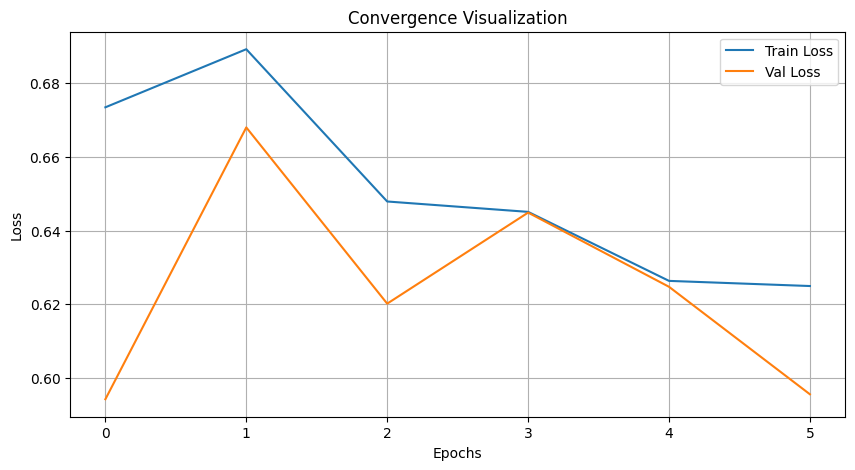

In [9]:
# PyTorch Data Pipeline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

df_final = df_final.sort_values(by=['fiscalYear', 'bankName']).reset_index(drop=True)
train_df = df_final[df_final['fiscalYear'] <= 2023].copy()
test_df = df_final[df_final['fiscalYear'] >= 2024].copy()

# Metric safety (ensure 2 classes)
for dftmp in [train_df, test_df]:
    if len(dftmp['isHighRisk'].unique()) < 2:
        dftmp.loc[dftmp.sample(frac=0.2).index, 'isHighRisk'] = 1 - dftmp['isHighRisk'].iloc[0]

X_cols = ['npaRatio', 'riskWeightRatio', 'restructuringStress']
scaler = StandardScaler(); scaler.fit(train_df[X_cols])

X_train_t = torch.tensor(scaler.transform(train_df[X_cols]), dtype=torch.float32)
X_test_t = torch.tensor(scaler.transform(test_df[X_cols]), dtype=torch.float32)
y_train_t = torch.tensor(train_df['isHighRisk'].values, dtype=torch.float32).reshape(-1, 1)
y_test_t = torch.tensor(test_df['isHighRisk'].values, dtype=torch.float32).reshape(-1, 1)

class BankDefaultDataset(Dataset):
    def __init__(self, X, y): self.X, self.y = X, y
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(BankDefaultDataset(X_train_t, y_train_t), batch_size=16, shuffle=True, num_workers=2, pin_memory=True if torch.cuda.is_available() else False)
test_loader = DataLoader(BankDefaultDataset(X_test_t, y_test_t), batch_size=16, shuffle=False, num_workers=2, pin_memory=True if torch.cuda.is_available() else False)

# Architecture Class
class CreditRiskANN(nn.Module):
    def __init__(self, input_dim, num_hidden_layers, neurons_per_layer, dropout_rate):
        super(CreditRiskANN, self).__init__()
        layers = []
        in_dim = input_dim
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(in_dim, neurons_per_layer))
            layers.append(nn.BatchNorm1d(neurons_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout_rate))
            in_dim = neurons_per_layer
        layers.append(nn.Linear(in_dim, 1))
        self.layers = nn.Sequential(*layers)
        self.apply(self._init_weights)
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            if m.out_features == 1: nn.init.xavier_normal_(m.weight)
            else: nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if m.bias is not None: nn.init.constant_(m.bias, 0)
    def forward(self, x): return self.layers(x)

# Optimization Study
def objective(trial):
    num_hidden_layers = trial.suggest_int('num_hidden_layers', 1, 4)
    neurons_per_layer = trial.suggest_int('neurons_per_layer', 32, 128, step=32)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    
    m = CreditRiskANN(len(X_cols), num_hidden_layers, neurons_per_layer, dropout_rate).to(device)
    opt = optim.Adam(m.parameters(), lr=learning_rate)
    crit = nn.BCEWithLogitsLoss()
    m.train()
    for e in range(20):
        for bf, bl in train_loader:
            bf, bl = bf.to(device), bl.to(device)
            opt.zero_grad(); crit(m(bf), bl).backward(); opt.step()
    m.eval(); corr, tot = 0, 0
    with torch.no_grad():
        for bf, bl in test_loader:
            preds = (torch.sigmoid(m(bf.to(device))) > 0.5).float()
            corr += (preds.cpu() == bl).sum().item(); tot += bl.size(0)
    return corr / tot

print("\nStarting Optuna Hyperparameter Optimization...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)
best_params = study.best_trial.params
print("\n--- Optuna Best Hyperparameters ---")
for k, v in best_params.items(): print(f"  {k}: {v}")

# Final Best Model
model = CreditRiskANN(len(X_cols), best_params['num_hidden_layers'], best_params['neurons_per_layer'], best_params['dropout_rate']).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=best_params['learning_rate'], weight_decay=1e-4)

# Advanced Training Loop
train_losses, val_losses = [], []
best_v, c = float('inf'), 0
print("\nTraining Final Model with Early Stopping...")
for epoch in range(100):
    model.train(); t_l = 0.0
    for bf, bl in train_loader:
        bf, bl = bf.to(device), bl.to(device); optimizer.zero_grad(); l = criterion(model(bf), bl); l.backward(); optimizer.step(); t_l += l.item()
    avg_t = t_l/len(train_loader); train_losses.append(avg_t)
    
    model.eval(); v_l = 0.0
    with torch.no_grad():
        for bf, bl in test_loader:
            bf, bl = bf.to(device), bl.to(device); out = model(bf); v_l += criterion(out, bl).item()
    avg_v = v_l/len(test_loader); val_losses.append(avg_v)
    
    print(f"Epoch {epoch+1}/100, Loss: {avg_t:.4f}, Val Loss: {avg_v:.4f}")
    
    if avg_v < best_v:
        best_v = avg_v; c = 0; torch.save(model.state_dict(), 'best_model.pth')
    else:
        c += 1
        if c >= 5: print(f"Early stopping triggered at epoch {epoch+1}"); break

model.load_state_dict(torch.load('best_model.pth'))

# Visualization (Train vs Val Loss Curve)
plt.figure(figsize=(10, 5)); plt.plot(train_losses, label='Train Loss'); plt.plot(val_losses, label='Val Loss')
plt.title('Convergence Visualization'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True); plt.show()

# Performance Reporting & Model Persistence

In [10]:
# Final Performance reporting
print("\n--- Final Performance Metrics (Test Set 2024-2025) ---")
model.eval(); ap, al = [], []
with torch.no_grad():
    for bf, bl in test_loader:
        logits = model(bf.to(device))
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        ap.extend(preds.cpu().numpy().flatten()); al.extend(bl.numpy().flatten())

y_t, y_p = np.array(al), np.array(ap)
print(f"Confusion Matrix:\n{confusion_matrix(y_t, y_p)}")
print(f"Accuracy:  {accuracy_score(y_t, y_p):.4f}")
print(f"Precision: {precision_score(y_t, y_p, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_t, y_p, zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_t, y_p, zero_division=0):.4f}")

# Model Saving
torch.save(model.state_dict(), 'credit_risk_model.pth')
print("\nModel saved to 'credit_risk_model.pth'")

# Model Loading Demo
print("\n--- Model Loading Demo ---")
loaded_model = CreditRiskANN(len(X_cols), best_params['num_hidden_layers'], best_params['neurons_per_layer'], best_params['dropout_rate']).to(device)
loaded_model.load_state_dict(torch.load('credit_risk_model.pth'))
loaded_model.eval()
print("Model re-instantiated and weights loaded successfully.")


--- Final Performance Metrics (Test Set 2024-2025) ---


Confusion Matrix:
[[  0  39]
 [  0 157]]
Accuracy:  0.8010
Precision: 0.8010
Recall:    1.0000
F1-Score:  0.8895

Model saved to 'credit_risk_model.pth'

--- Model Loading Demo ---
Model re-instantiated and weights loaded successfully.
